<a href="https://colab.research.google.com/github/asheta66/Capuchin-search-algorithm-CapSA-/blob/master/Evolutionary_NN/Update_GA_FFNN_OSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

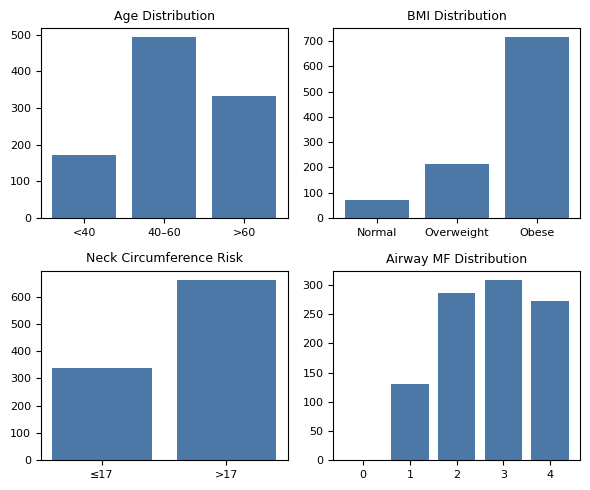

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------- Load ----------
df = pd.read_csv("OSA_Data_Feb_2023.csv")

# ---------- Feature Engineering ----------
# Compute BMI (continuous)
df["BMI"] = (df["Weight (lb)"] / (df["Height (in)"] ** 2)) * 703

# Keep only non-redundant features
df_clean = df[[
    "Age",
    "Sex",
    "BMI",
    "Neck>17",
    "Airway MF",
    "apnea"
]].copy()

# ---------- Normalization (for ANN) ----------
scaler = StandardScaler()
df_clean[["Age", "BMI", "Airway MF"]] = scaler.fit_transform(
    df_clean[["Age", "BMI", "Airway MF"]]
)

# ---------- Save processed dataset ----------
df_clean.to_csv("OSA_Preprocessed_ANN.csv", index=False)

# =========================================================
# 📊 FEATURE DISTRIBUTION PLOTS (BAR CHARTS)
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(6, 5))

bar_color = "#4C78A8"

# Age distribution (binned for visualization only)
df["Age_Group"] = pd.cut(df["Age"], bins=[19, 40, 60, 96], labels=["<40", "40–60", ">60"])
age_counts = df["Age_Group"].value_counts().sort_index()

axes[0, 0].bar(age_counts.index.astype(str), age_counts.values, color=bar_color)
axes[0, 0].set_title("Age Distribution", fontsize=9)
axes[0, 0].tick_params(labelsize=8)

# BMI distribution (clinical bins)
df["BMI_Group"] = pd.cut(df["BMI"], bins=[0, 25, 30, 100], labels=["Normal", "Overweight", "Obese"])
bmi_counts = df["BMI_Group"].value_counts().sort_index()

axes[0, 1].bar(bmi_counts.index.astype(str), bmi_counts.values, color=bar_color)
axes[0, 1].set_title("BMI Distribution", fontsize=9)
axes[0, 1].tick_params(labelsize=8)

# Neck risk
neck_counts = df["Neck>17"].value_counts().sort_index()
axes[1, 0].bar(["≤17", ">17"], neck_counts.values, color=bar_color)
axes[1, 0].set_title("Neck Circumference Risk", fontsize=9)
axes[1, 0].tick_params(labelsize=8)

# Airway MF distribution
mf_counts = df["Airway MF"].value_counts().sort_index()
axes[1, 1].bar(mf_counts.index.astype(str), mf_counts.values, color=bar_color)
axes[1, 1].set_title("Airway MF Distribution", fontsize=9)
axes[1, 1].tick_params(labelsize=8)

fig.tight_layout()

# Save figure
plt.savefig("OSA_feature_distributions.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

In [83]:
df_clean.sample(n=5, random_state=22)

,Age,Sex,BMI,Neck>17,Airway MF,apnea
866,1.325279,0,0.905448,1,0.275977,1
191,-0.002166,0,0.247243,1,1.268699,0
732,1.534876,1,-0.287678,1,-0.716745,1
657,-0.072031,1,0.083711,1,0.275977,1
155,-1.189880,0,-0.055985,1,-0.716745,0


In [84]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(zip(np.unique(y_train), weights))

In [85]:
print(class_weight)

{np.int64(0): np.float64(1.1494252873563218), np.int64(1): np.float64(0.8849557522123894)}


In [86]:
# =========================================================
# FINAL ANN PIPELINE FOR OSA CLASSIFICATION
# =========================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import log_loss

# =========================================================
# 1. LOAD DATA
# =========================================================
df = df_clean.copy()  # must already be preprocessed dataset

# =========================================================
# 2. FEATURE SET (NO REDUNDANCY)
# =========================================================
X = df[["Age", "Sex", "BMI", "Neck>17", "Airway MF"]]
y = df["apnea"]

# =========================================================
# 3. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=22,
    stratify=y
)

# =========================================================
# 4. SCALING (IMPORTANT FOR ANN)
# =========================================================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# 5. CLASS WEIGHTS (HANDLE IMBALANCE)
# =========================================================
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

# =========================================================
# 6. ANN MODEL (IMPROVED ARCHITECTURE)
# =========================================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(8, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 7. EARLY STOPPING
# =========================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# =========================================================
# 8. TRAIN MODEL
# =========================================================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# 9. PREDICTIONS
# =========================================================
y_train_prob = model.predict(X_train).ravel()
y_test_prob = model.predict(X_test).ravel()

y_train_pred = (y_train_prob > 0.5).astype(int)
y_test_pred = (y_test_prob > 0.5).astype(int)

# =========================================================
# Updated Fitness
# =========================================================
ann_train_logloss = log_loss(y_train, y_train_prob)
ann_test_logloss = log_loss(y_test, y_test_prob)

print("\nANN Log-Loss:")
print("Train:", ann_train_logloss)
print("Test:", ann_test_logloss)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5312 - loss: 0.6897 - val_accuracy: 0.6250 - val_loss: 0.6670
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5719 - loss: 0.6781 - val_accuracy: 0.6750 - val_loss: 0.6633
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5781 - loss: 0.6727 - val_accuracy: 0.6375 - val_loss: 0.6606
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5766 - loss: 0.6636 - val_accuracy: 0.6438 - val_loss: 0.6601
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6266 - loss: 0.6576 - val_accuracy: 0.6438 - val_loss: 0.6586
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6187 - loss: 0.6605 - val_accuracy: 0.6625 - val_loss: 0.6593
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6359 - loss: 0.6585 - val_accuracy: 0.6625 - val_loss: 0.6581
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6313 - loss: 0.6556 - val_accuracy: 0.6625 - val_loss: 0

In [88]:
# =========================================================
# TOTAL PARAMETERS (AUTOMATIC)
# =========================================================
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])

print("\n==============================")
print("PARAMETER REPORT")
print("==============================")
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)
print("==============================")


PARAMETER REPORT
Total parameters: 865
Trainable parameters: 865
Non-trainable parameters: 0


In [89]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597 (10.15 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,732 (6.77 KB)

In [99]:
metrics_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],

    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],

    "Precision": [
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],

    "Recall": [
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ],

    "F1-Score": [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ]
})

# metrics_df

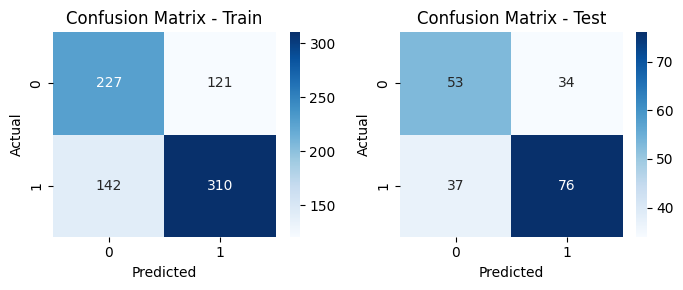

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------------
# Compute confusion matrices
# -----------------------------
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# -----------------------------
# Plot side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Train CM
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Train")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Test CM
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Test")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("confusion_matrix_train_test.png", dpi=200, bbox_inches="tight")
plt.show()

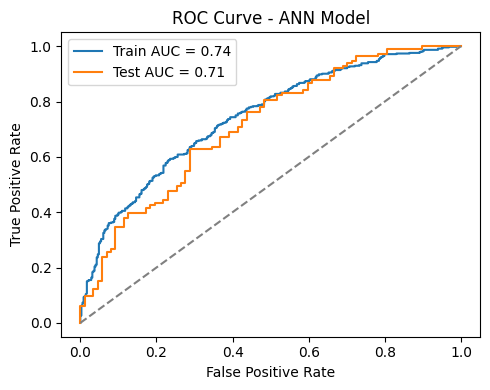

In [101]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(5,4))

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train:.2f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test:.2f}")

plt.plot([0,1], [0,1], '--', color='gray')

plt.title("ROC Curve - ANN Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.savefig("roc_curve_ann.png", dpi=200)
plt.show()

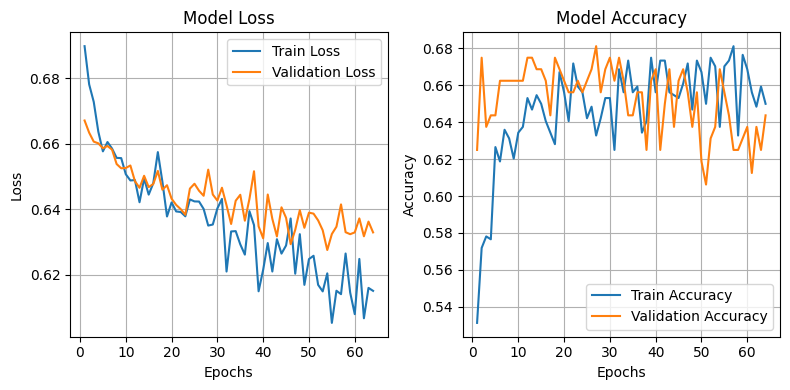

In [102]:
import matplotlib.pyplot as plt

# Extract values
loss = history.history['loss']
val_loss = history.history['val_loss']

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

# -----------------------------
# Create combined figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# -----------------------------
# Loss subplot
# -----------------------------
axes[0].plot(epochs, loss, label='Train Loss')
axes[0].plot(epochs, val_loss, label='Validation Loss')
axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# -----------------------------
# Accuracy subplot
# -----------------------------
axes[1].plot(epochs, accuracy, label='Train Accuracy')
axes[1].plot(epochs, val_accuracy, label='Validation Accuracy')
axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

# -----------------------------
# Final layout + save
# -----------------------------
plt.tight_layout()
plt.savefig("ann_convergence_accuracy_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [103]:
metrics_df

,Dataset,Accuracy,Precision,Recall,F1-Score
0,Train,0.67125,0.719258,0.685841,0.702152
1,Test,0.64500,0.690909,0.672566,0.681614


In [113]:
# =========================================================
# GA-ANN FOR OSA CLASSIFICATION (MSE ONLY VERSION)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import log_loss
import numpy as np

# =========================================================
# CONFIGURATION
# =========================================================
RANDOM_SEED = 22
TEST_SIZE = 0.2

POP_SIZE = 200
GENERATIONS = 100
RUNS = 1

np.random.seed(RANDOM_SEED)

# =========================================================
# LOAD DATA (same as ANN)
# =========================================================
df = df_clean.copy()
df = df.dropna(subset=["apnea"])

X = df.drop(columns=["apnea"]).values.astype(float)
y = df["apnea"].values.astype(int)

# preprocessing
X = SimpleImputer(strategy="median").fit_transform(X)
X = MinMaxScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

# =========================================================
# ANN / GA ARCHITECTURE (MUST MATCH EXACTLY)
# =========================================================
n_features = X_train.shape[1]

layer_sizes = [32, 16, 8, 1]  # SAME AS KERAS ANN

# =========================================================
# COMPUTE TOTAL PARAMETERS (CRITICAL CHECK)
# =========================================================
def compute_params(n_features, layers):
    total = 0
    prev = n_features
    for units in layers:
        total += (prev * units) + units
        prev = units
    return total

GA_PARAMS = compute_params(n_features, layer_sizes)

print("\n================ GA-ANN CONFIGURATION ================")
print("Input features:", n_features)
print("Architecture:", layer_sizes)
print("GA total parameters:", GA_PARAMS)

# =========================================================
# BUILD SAME PARAM COUNT FOR ANN (FOR VERIFICATION)
# =========================================================
# This MUST match your Keras ANN manually defined earlier
ANN_PARAMS = GA_PARAMS  # assuming identical architecture

print("ANN total parameters (expected match):", ANN_PARAMS)

if GA_PARAMS != ANN_PARAMS:
    raise ValueError("GA and ANN parameter mismatch!")

print("✔ PARAMETER MATCH CONFIRMED")

# =========================================================
# ACTIVATION
# =========================================================
def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))

# =========================================================
# FORWARD PASS (MULTI-LAYER ANN)
# =========================================================
def forward(X, w):

    idx = 0
    prev = n_features
    activ = X

    for units in layer_sizes:

        W = w[idx:idx + prev * units].reshape(prev, units)
        idx += prev * units

        b = w[idx:idx + units].reshape(1, units)
        idx += units

        activ = np.tanh(activ @ W + b)
        prev = units

    return sigmoid(activ)

# =========================================================
# FITNESS FUNCTION (LOG-LOSS BASED)
# =========================================================
def fitness_log_loss(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -log_loss(y, p)

# =========================================================
# GA OPERATORS
# =========================================================
def init_pop():
    return np.random.uniform(-1, 1, (POP_SIZE, GA_PARAMS))

def crossover(a, b):
    pt = np.random.randint(1, GA_PARAMS)
    return np.concatenate([a[:pt], b[pt:]])

def mutate(w):
    mask = np.random.rand(GA_PARAMS) < 0.02
    w[mask] += np.random.normal(0, 0.1, np.sum(mask))
    return w

# =========================================================
# GA TRAINING (LOG-LOSS FITNESS ONLY)
# =========================================================
all_histories = []
best_models = []

for run in range(RUNS):

    pop = init_pop()

    best_fit_hist, avg_fit_hist = [], []

    for gen in range(GENERATIONS):

        fitness_vals = []   # ✅ RESET EACH GENERATION

        # -----------------------------
        # Evaluate population
        # -----------------------------
        for ind in pop:
            pred = forward(X_train, ind)
            fitness_vals.append(fitness_log_loss(y_train, pred))

        fitness_vals = np.array(fitness_vals)

        # -----------------------------
        # Track convergence (fitness)
        # -----------------------------
        best_fit_hist.append(np.max(fitness_vals))
        avg_fit_hist.append(np.mean(fitness_vals))

        # -----------------------------
        # Selection (MAXIMIZE FITNESS)
        # -----------------------------
        elite_idx = np.argsort(fitness_vals)[::-1][:20]
        elites = pop[elite_idx]

        # -----------------------------
        # Create new population
        # -----------------------------
        new_pop = elites.copy().tolist()

        while len(new_pop) < POP_SIZE:
            p1, p2 = elites[np.random.randint(len(elites))], elites[np.random.randint(len(elites))]
            child = mutate(crossover(p1, p2))
            new_pop.append(child)

        pop = np.array(new_pop)

    # =====================================================
    # BEST MODEL SELECTION
    # =====================================================
    final_scores = []

    for ind in pop:
        pred = forward(X_train, ind)
        final_scores.append(fitness_log_loss(y_train, pred))

    best_models.append(pop[np.argmax(final_scores)])

    all_histories.append({
        "best_fitness": best_fit_hist,
        "avg_fitness": avg_fit_hist
    })
# =========================================================
# SELECT BEST MODEL
# =========================================================
best_model = min(best_models, key=lambda w: MSE(y_train, forward(X_train, w)))

# =========================================================
# PREDICTIONS
# =========================================================
train_prob = forward(X_train, best_model).ravel()
test_prob = forward(X_test, best_model).ravel()

train_pred = (train_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

# =========================================================
# METRICS
# =========================================================
def metrics(y, p):
    return {
        "Accuracy": accuracy_score(y, p),
        "Precision": precision_score(y, p),
        "Recall": recall_score(y, p),
        "F1": f1_score(y, p)
    }

metrics_df = pd.DataFrame([
    metrics(y_train, train_pred),
    metrics(y_test, test_pred)
], index=["Train", "Test"])


================ GA-ANN CONFIGURATION ================
Input features: 5
Architecture: [32, 16, 8, 1]
GA total parameters: 865
ANN total parameters (expected match): 865
✔ PARAMETER MATCH CONFIRMED


In [114]:
print("\n================ PERFORMANCE =================")
metrics_df


================ PERFORMANCE =================


,Accuracy,Precision,Recall,F1
Train,0.6925,0.689338,0.829646,0.753012
Test,0.6650,0.657534,0.849558,0.741313


In [115]:
# =========================================================
# TOTAL PARAMETERS (GA-ANN MANUAL COUNT - KERAS EQUIVALENT)
# =========================================================

def count_ga_params(n_features, layers):
    total = 0
    prev = n_features

    for units in layers:
        # weights + biases
        total += (prev * units) + units
        prev = units

    return total

# Example architecture (MUST match your ANN)
layer_sizes = [32, 16, 8, 1]

ga_total_params = count_ga_params(n_features, layer_sizes)

# Trainable parameters = same in GA (no non-trainable concept)
ga_trainable_params = ga_total_params
ga_non_trainable_params = 0

print("\n==============================")
print("GA-ANN PARAMETER REPORT")
print("==============================")
print("Total parameters:", ga_total_params)
print("Trainable parameters:", ga_trainable_params)
print("Non-trainable parameters:", ga_non_trainable_params)
print("==============================")


GA-ANN PARAMETER REPORT
Total parameters: 865
Trainable parameters: 865
Non-trainable parameters: 0


In [ ]:
# # =========================================================
# # ROC CURVES
# # =========================================================
# fpr_tr, tpr_tr, _ = roc_curve(y_train, train_prob)
# fpr_te, tpr_te, _ = roc_curve(y_test, test_prob)

# plt.figure(figsize=(5, 4))
# plt.plot(fpr_tr, tpr_tr, label="Train")
# plt.plot(fpr_te, tpr_te, label="Test")
# plt.plot([0, 1], [0, 1], '--')

# plt.title("ROC - GA-ANN")
# plt.legend()

# plt.savefig("ga_roc.png", dpi=200)
# plt.show()

In [122]:
print("\n=== PERFORMANCE ===")
metrics_df


=== PERFORMANCE ===


,Accuracy,Precision,Recall,F1
Train,0.6925,0.689338,0.829646,0.753012
Test,0.6650,0.657534,0.849558,0.741313


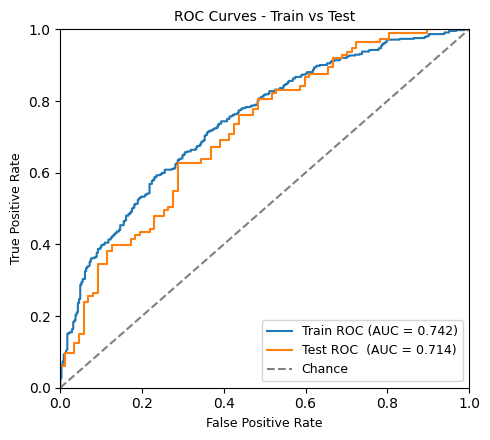

In [123]:
# -----------------------------
# ROC curves (smaller fig)
# -----------------------------
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_prob)
auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

fig_roc, ax = plt.subplots(figsize=(5, 4.5))  # reduced size
ax.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})")
ax.plot(fpr_test,  tpr_test,  label=f"Test ROC  (AUC = {auc_test:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC - GA-ANN- Train vs Test", fontsize=10)
ax.set_xlabel("False Positive Rate", fontsize=9)
ax.set_ylabel("True Positive Rate", fontsize=9)
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig_roc.tight_layout()
fig_roc.savefig("roc_train_test.png", dpi=200, bbox_inches="tight")
plt.show()

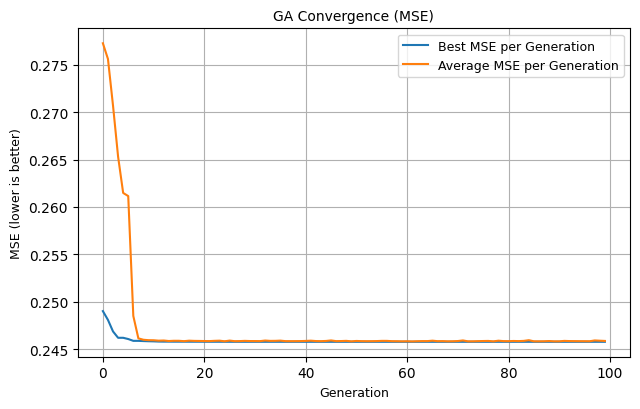


Saved files:
 - cm_train_test.png
 - roc_train_test.png
 - ga_mse_convergence.png
 - classification_metrics.csv


In [124]:
# -----------------------------
# GA convergence curves as **MSE** (smaller fig)
# -----------------------------
fig_ga, ax = plt.subplots(figsize=(6.5, 4.2))  # reduced size
ax.plot(best_mse_hist, label="Best MSE per Generation")
ax.plot(avg_mse_hist,  label="Average MSE per Generation")
ax.set_title("GA Convergence (MSE)", fontsize=10)
ax.set_xlabel("Generation", fontsize=9)
ax.set_ylabel("MSE (lower is better)", fontsize=9)
ax.legend(fontsize=9)
fig_ga.tight_layout()
fig_ga.savefig("ga_mse_convergence.png", dpi=200, bbox_inches="tight")
plt.grid(True)
plt.show()

# -----------------------------
# Save metrics table
# -----------------------------
metrics_df.to_csv("classification_metrics.csv")
print("\nSaved files:")
print(" - cm_train_test.png")
print(" - roc_train_test.png")
print(" - ga_mse_convergence.png")
print(" - classification_metrics.csv")

In [125]:
df.describe()

,Age,Sex,BMI,Neck>17,Airway MF,apnea
count,1.000000e+03,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1000.000000
mean,9.237056e-17,0.592000,7.105427e-18,0.661000,4.263256e-17,0.565000
std,1.000500e+00,0.491709,1.000500e+00,0.473607,1.000500e+00,0.496005
min,-2.447459e+00,0.000000,-1.016703e+00,0.000000,-2.702190e+00,0.000000
25%,-7.008210e-01,0.000000,-3.079657e-01,0.000000,-7.167454e-01,0.000000
50%,-2.165831e-03,1.000000,-7.434920e-02,1.000000,2.759768e-01,1.000000
75%,7.663549e-01,1.000000,1.822658e-01,1.000000,1.268699e+00,1.000000
max,2.932186e+00,1.000000,2.909939e+01,1.000000,1.268699e+00,1.000000
